### Célula 1 — Imports e Configuração Inicial
Importamos todas as bibliotecas necessárias (pandas, numpy, matplotlib, seaborn, wordcloud) e aplicamos configurações visuais padrão. Também verificamos as versões de pandas e numpy para garantir reprodutibilidade.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
sns.set_palette("husl")
pd.set_option("display.max_colwidth", 100)

print("✅ Imports carregados com sucesso!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

✅ Imports carregados com sucesso!
pandas: 3.0.2
numpy: 2.4.4


### Célula 2 — Carregamento do Dataset
Carregamos o arquivo `IMDB Dataset.csv` e realizamos uma primeira inspeção: dimensões do DataFrame, nomes e tipos das colunas, e visualização das três primeiras linhas.

In [ ]:
df = pd.read_csv('../data/raw/IMDB Dataset.csv')

print("="*50)
print("INFORMAÇÕES BÁSICAS DO DATASET")
print("="*50)
print(f"\n📊 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\n📋 Colunas: {list(df.columns)}")
print(f"\n🔍 Tipos de dados:")
print(df.dtypes)
print(f"\n📝 Primeiras 3 linhas:")
df.head(3)

INFORMAÇÕES BÁSICAS DO DATASET

📊 Shape: 50,000 linhas × 2 colunas

📋 Colunas: ['review', 'sentiment']

🔍 Tipos de dados:
review       str
sentiment    str
dtype: object

📝 Primeiras 3 linhas:


,review,sentiment
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive


### Célula 3 — Verificação de Qualidade dos Dados
Verificamos a integridade dos dados: valores ausentes, linhas duplicadas e distribuição da variável alvo (`sentiment`). Conferimos que o dataset é perfeitamente balanceado (50% positivo, 50% negativo) e não contém nulos.

In [18]:
print("="*50)
print("VERIFICAÇÃO DE QUALIDADE DOS DADOS")
print("="*50)

# Valores nulos
print(f"\nValores nulos por coluna:")
print(df.isnull().sum())

# Duplicatas
duplicatas = df.duplicated().sum()
print(f"\nLinhas duplicadas: {duplicatas}")

# Distribuição da variável alvo
print(f"\nDistribuição de sentimentos:")
print(df['sentiment'].value_counts())
print(f"\nProporção:")
print(df['sentiment'].value_counts(normalize=True).round(3))

VERIFICAÇÃO DE QUALIDADE DOS DADOS

Valores nulos por coluna:
review           0
sentiment        0
n_chars          0
n_words          0
n_sentences      0
n_exclamation    0
n_question       0
n_caps_words     0
caps_ratio       0
label            0
dtype: int64

Linhas duplicadas: 418

Distribuição de sentimentos:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Proporção:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


### Célula 2.1 — Distribuição da Variável Alvo
Visualizamos a distribuição das classes de sentimento com um gráfico de barras e um gráfico de pizza, confirmando o balanceamento e salvando a figura em `reports/figures/`.

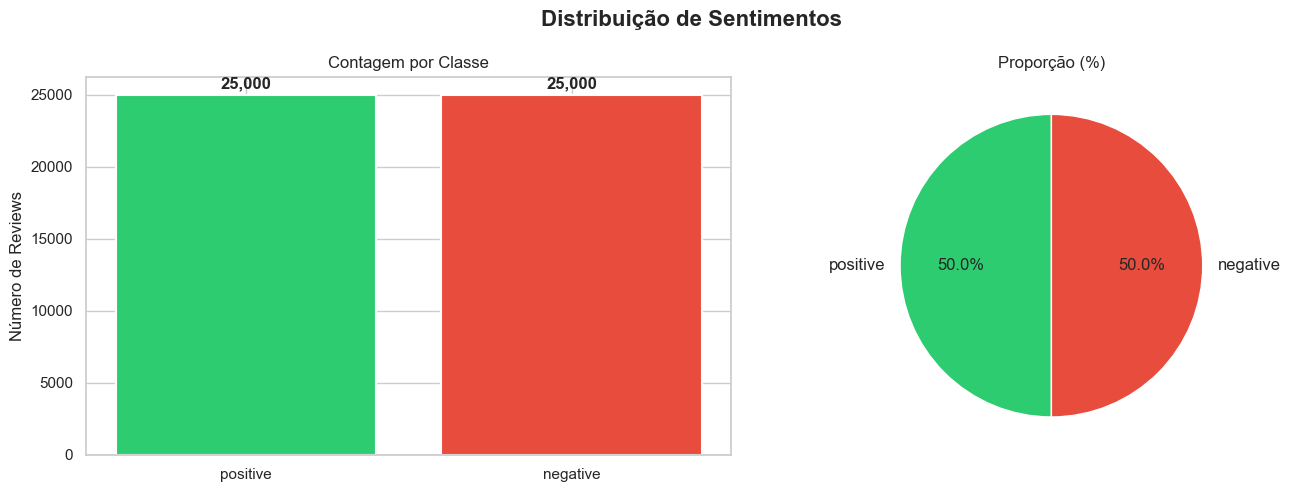

Gráfico salvo em reports/figures/


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Sentimentos', fontsize=16, fontweight='bold')

# Gráfico 1
counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # verde para positivo, vermelho para negativo
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Número de Reviews')

for bar, value in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{value:,}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção (%)')

plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_sentimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em reports/figures/")

### Célula 2.2 — Comprimento das Reviews
Aqui criamos novas colunas com o número de caracteres, palavras e sentenças de cada review. Exibimos estatísticas descritivas agrupadas por sentimento e geramos histogramas comparativos para identificar possíveis diferenças de comprimento entre reviews positivas e negativas.

COMPRIMENTO MÉDIO POR SENTIMENTO
          n_chars        n_words        n_sentences       
             mean median    mean median        mean median
sentiment                                                 
negative   1294.1  973.0   229.5  174.0        12.0   10.0
positive   1324.8  968.0   232.8  172.0        11.8    9.0


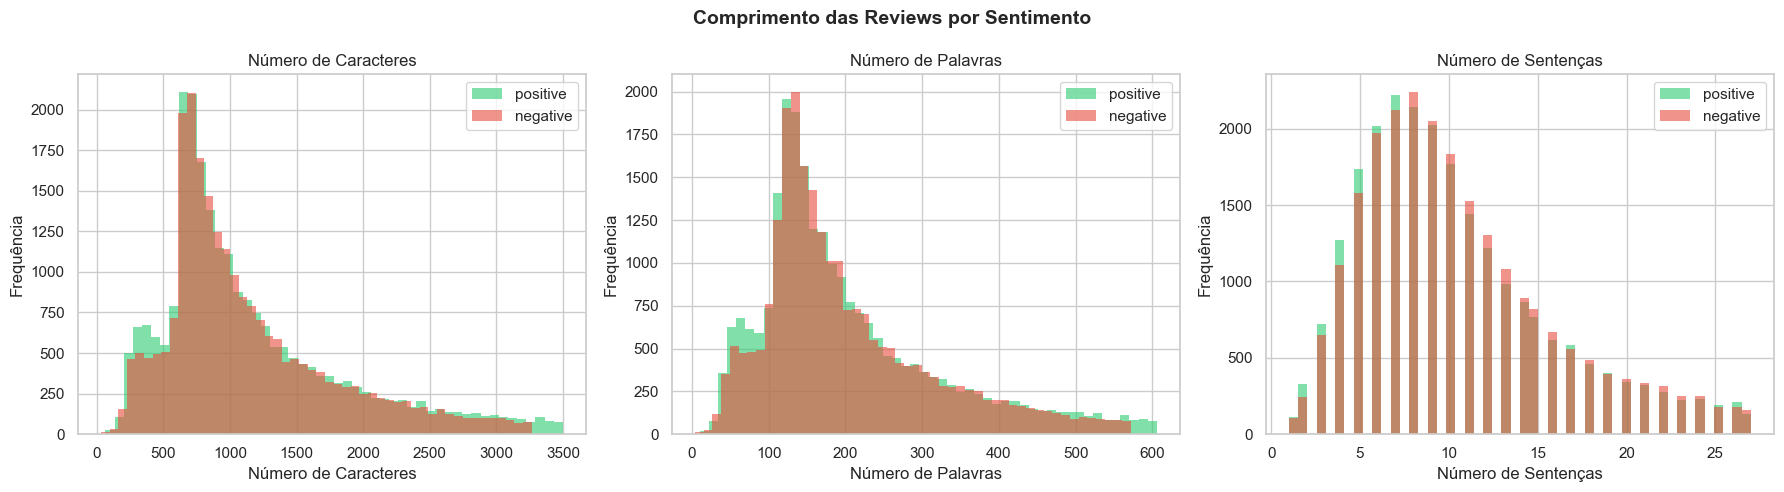

In [ ]:
df['n_chars'] = df['review'].apply(len)
df['n_words'] = df['review'].apply(lambda x: len(x.split()))
df['n_sentences'] = df['review'].apply(lambda x: len([s for s in x.split('.') if len(s) > 5]))

print("COMPRIMENTO MÉDIO POR SENTIMENTO")
print("="*50)
stats = df.groupby('sentiment')[['n_chars', 'n_words', 'n_sentences']].agg(['mean', 'median'])
print(stats.round(1))

# Graficos de distribuição
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comprimento das Reviews por Sentimento', fontsize=14, fontweight='bold')

features = ['n_chars', 'n_words', 'n_sentences']
titles = ['Número de Caracteres', 'Número de Palavras', 'Número de Sentenças']

for ax, feat, title in zip(axes, features, titles):
    for sentiment, color in zip(['positive', 'negative'], ['#2ecc71', '#e74c3c']):
        subset = df[df['sentiment'] == sentiment][feat]
        # decudi plotar até o 95º percentil para evitar distorção por outliers
        ax.hist(subset[subset < subset.quantile(0.95)],
                bins=50, alpha=0.6, color=color, label=sentiment, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/02_comprimento_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

### Célula 2.3 — Análise de Caracteres Especiais e Emoção
Calculamos features baseadas em pontuação e capitalização: quantidade de exclamações, interrogações, palavras totalmente em maiúsculas e proporção de letras maiúsculas. Analisamos as médias por sentimento e geramos um heatmap de correlação entre essas novas features e o label positivo.


Média de exclamações por sentimento:
sentiment
negative    1.027
positive    0.940
Name: n_exclamation, dtype: float64

Média de palavras em CAPS por sentimento:
sentiment
negative    1.690
positive    1.441
Name: n_caps_words, dtype: float64

Correlação das features com sentimento positivo:
caps_ratio       0.0299
n_chars          0.0155
n_words          0.0099
n_sentences     -0.0110
n_exclamation   -0.0137
n_caps_words    -0.0350
n_question      -0.1704
Name: label, dtype: float64


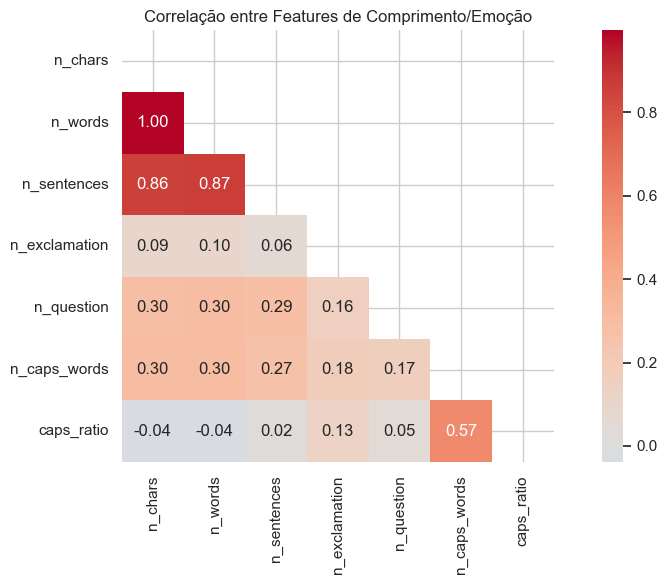

In [ ]:
df['n_exclamation'] = df['review'].apply(lambda x: x.count('!'))
df['n_question']    = df['review'].apply(lambda x: x.count('?'))
df['n_caps_words']  = df['review'].apply(lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 2))
df['caps_ratio']    = df['review'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

print("\nMédia de exclamações por sentimento:")
print(df.groupby('sentiment')['n_exclamation'].mean().round(3))

print("\nMédia de palavras em CAPS por sentimento:")
print(df.groupby('sentiment')['n_caps_words'].mean().round(3))

# Correlação dessas features com o sentimento
df['label'] = (df['sentiment'] == 'positive').astype(int)
extra_features = ['n_chars', 'n_words', 'n_sentences', 'n_exclamation',
                  'n_question', 'n_caps_words', 'caps_ratio']

correlations = df[extra_features + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print("\nCorrelação das features com sentimento positivo:")
print(correlations.round(4))

# Heatmap de correlações
plt.figure(figsize=(10, 6))
corr_matrix = df[extra_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlação entre Features de Comprimento/Emoção')
plt.tight_layout()
plt.savefig('../reports/figures/03_correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Célula 2.4 — Palavras Mais Frequentes
Aplicamos uma limpeza textual mínima (remoção de HTML, pontuação e espaços extras) e filtramos stopwords. Em seguida, extraímos e exibimos as 20 palavras mais comuns em reviews positivas e negativas, usando `Counter`.

In [ ]:
from collections import Counter
import re

# Função auxiliar de limpeza MÍNIMA (apenas nesta celula, só para EDA, não para o modelo)
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML
    text = re.sub(r'[^a-z\s]', ' ', text)       # só letras
    text = re.sub(r'\s+', ' ', text).strip()    # remove espaços extras
    return text

# Stopwords do NLTK
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=30):
    all_words = []
    for text in texts:
        cleaned = basic_clean(text)
        words = [w for w in cleaned.split() if w not in stop_words and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Top palavras por sentimento
print("TOP 20 PALAVRAS - REVIEWS POSITIVAS:")
pos_words = get_top_words(df[df['sentiment']=='positive']['review'])
for word, count in pos_words[:20]:
    print(f"  {word}: {count:,}")

print("\nTOP 20 PALAVRAS - REVIEWS NEGATIVAS:")
neg_words = get_top_words(df[df['sentiment']=='negative']['review'])
for word, count in neg_words[:20]:
    print(f"  {word}: {count:,}")

TOP 20 PALAVRAS - REVIEWS POSITIVAS:
  film: 42,111
  movie: 37,854
  one: 27,320
  like: 17,714
  good: 15,025
  great: 12,964
  story: 12,935
  time: 12,752
  well: 12,729
  see: 12,276
  also: 10,793
  really: 10,740
  would: 10,595
  even: 9,618
  first: 9,230
  much: 9,202
  people: 8,719
  love: 8,692
  best: 8,510
  get: 8,286

TOP 20 PALAVRAS - REVIEWS NEGATIVAS:
  movie: 50,118
  film: 37,597
  one: 26,283
  like: 22,458
  even: 15,254
  good: 14,728
  bad: 14,726
  would: 14,007
  time: 12,357
  really: 12,355
  see: 10,753
  story: 10,186
  get: 10,136
  much: 10,118
  people: 9,469
  make: 9,354
  could: 9,300
  made: 8,801
  well: 8,540
  first: 8,353


### Célula 2.5 — Nuvens de Palavras (Wordclouds)
Geramos nuvens de palavras para cada classe de sentimento, destacando visualmente os termos mais característicos de reviews positivas (fundo branco, tons verdes) e negativas (fundo preto, tons vermelhos). Salvamos a figura como `04_wordclouds.png`.

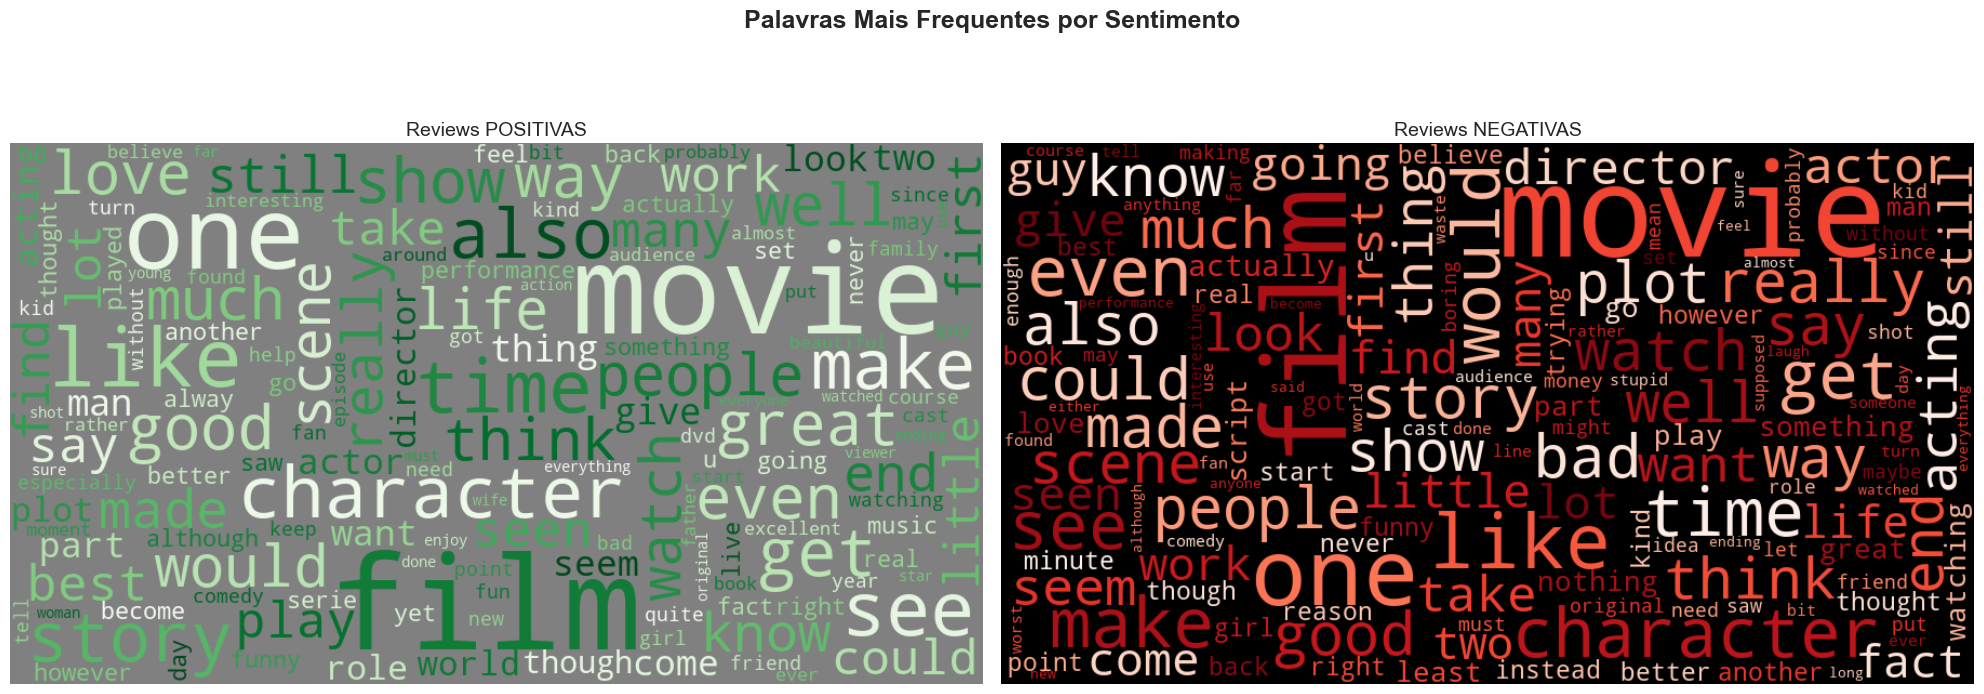

Palavras que aparecem nos DOIS grupos são menos discriminativas.
Palavras exclusivas de um grupo são as mais valiosas para o modelo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Palavras Mais Frequentes por Sentimento', fontsize=18, fontweight='bold')

# Positivas
pos_text = ' '.join(df[df['sentiment']=='positive']['review'].apply(basic_clean))
pos_wc = WordCloud(
    width=900, height=500,
    background_color='Gray', # decidi usar cinza para destacar melhor as palavras (verde claro fica mais visível em fundo cinza do que branco)
    colormap='Greens',
    max_words=150,
    stopwords=stop_words,
    min_font_size=10,
    max_font_size=120
).generate(pos_text)

axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Reviews POSITIVAS', fontsize=14)
axes[0].axis('off')

# Negativas
neg_text = ' '.join(df[df['sentiment']=='negative']['review'].apply(basic_clean))
neg_wc = WordCloud(
    width=900, height=500,
    background_color='black',
    colormap='Reds',
    max_words=150,
    stopwords=stop_words,
    min_font_size=10,
    max_font_size=120
).generate(neg_text)

axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Reviews NEGATIVAS', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

print("Palavras que aparecem nos DOIS grupos são menos discriminativas.")
print("Palavras exclusivas de um grupo são as mais valiosas para o modelo.")

### Célula 2.6 — Análise de N-gramas (Bigramas e Trigramas)
Utilizamos `CountVectorizer` para extrair os bigramas e trigramas mais frequentes em cada sentimento. Os gráficos de barras horizontais evidenciam combinações importantes, como "waste time" ou "not good", que ajudam o modelo a capturar negações e contextos.

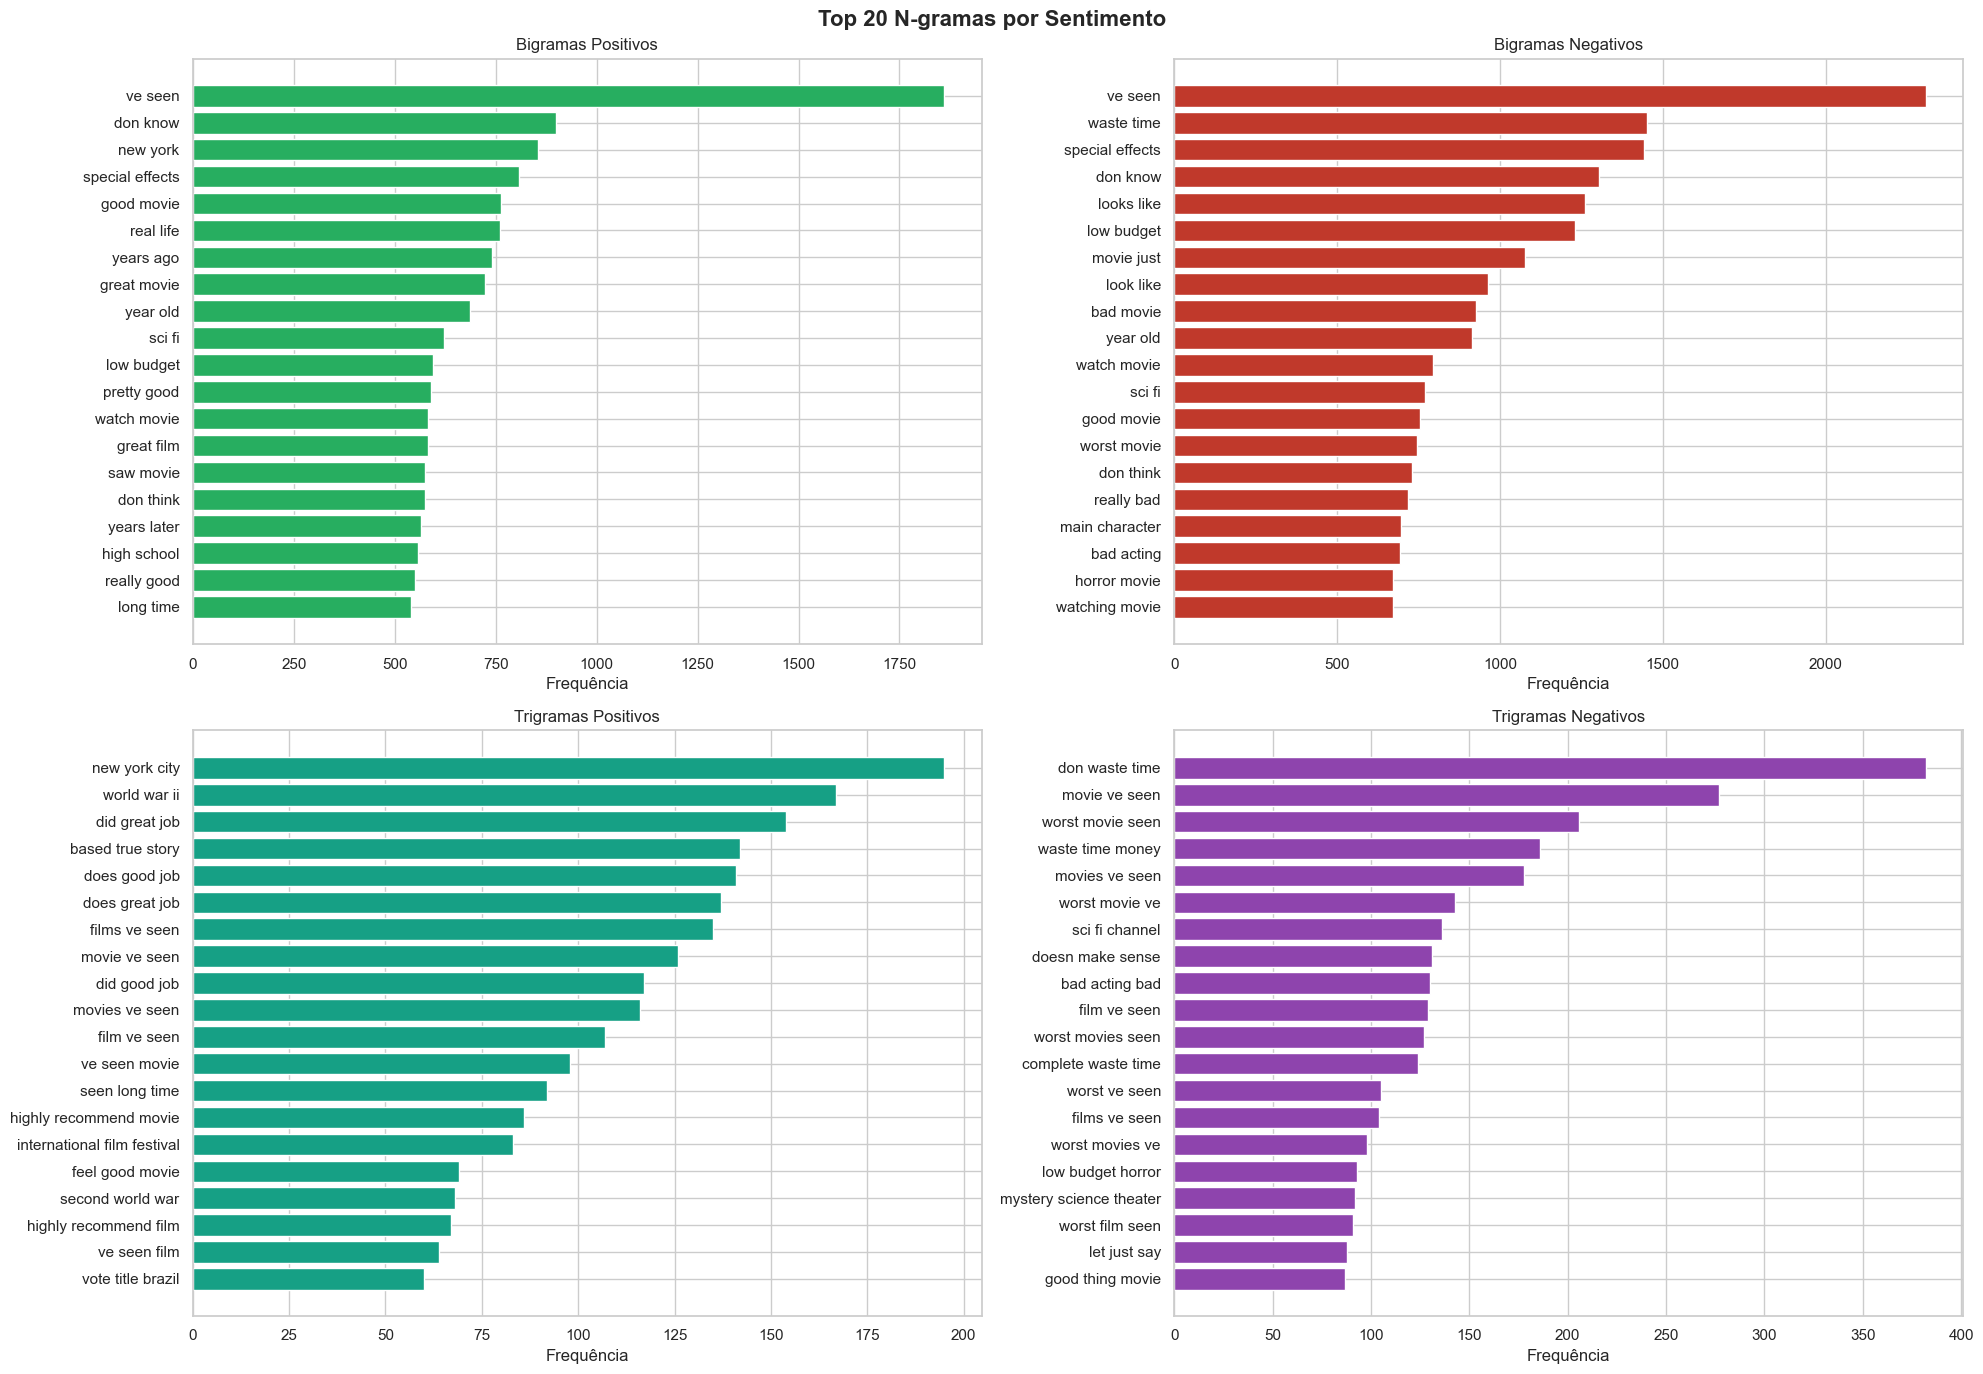

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(texts, title, n=2, top_k=20, ax=None, color='steelblue'):
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=5000
    )
    X = vec.fit_transform(texts.apply(basic_clean))
    
    totals = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_idx = totals.argsort()[-top_k:][::-1]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.barh([vocab[i] for i in top_idx[::-1]],
            [totals[i] for i in top_idx[::-1]],
            color=color, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frequência')
    return ax

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Top 20 N-gramas por Sentimento', fontsize=16, fontweight='bold')

plot_top_ngrams(df[df['sentiment']=='positive']['review'],
                'Bigramas Positivos', n=2, ax=axes[0,0], color='#27ae60')
plot_top_ngrams(df[df['sentiment']=='negative']['review'],
                'Bigramas Negativos', n=2, ax=axes[0,1], color='#c0392b')
plot_top_ngrams(df[df['sentiment']=='positive']['review'],
                'Trigramas Positivos', n=3, ax=axes[1,0], color='#16a085')
plot_top_ngrams(df[df['sentiment']=='negative']['review'],
                'Trigramas Negativos', n=3, ax=axes[1,1], color='#8e44ad')

plt.tight_layout()
plt.savefig('../reports/figures/05_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()

### Célula 2.7 — Exemplos Qualitativos: Reviews Extremas e Irônicas
Examinamos reviews com maior e menor número de palavras, além de reviews negativas com muitas exclamações (possível ironia). Isso ajuda a entender padrões desafiadores que o modelo precisará enfrentar.

In [22]:
print("REVIEWS COM MAIS PALAVRAS (positivas):")
print("="*60)
for _, row in df[df['sentiment']=='positive'].nlargest(3, 'n_words').iterrows():
    print(f"Palavras: {row['n_words']}")
    print(row['review'][:300] + "...\n")

print("\nREVIEWS COM MENOS PALAVRAS (negativas):")
print("="*60)
for _, row in df[df['sentiment']=='negative'].nsmallest(3, 'n_words').iterrows():
    print(f"Palavras: {row['n_words']}")
    print(row['review'][:300] + "...\n")

# Também examine reviews "difíceis" — ironia, sarcasmo
print("\nREVIEWS NEGATIVAS COM MUITAS EXCLAMAÇÕES (podem conter ironia):")
ironic = df[(df['sentiment']=='negative') & (df['n_exclamation'] > 5)]
if len(ironic) > 0:
    print(ironic['review'].iloc[0][:400])

REVIEWS COM MAIS PALAVRAS (positivas):
Palavras: 2470
Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get...

Palavras: 2278
There's a sign on The Lost Highway that says:<br /><br />*MAJOR SPOILERS AHEAD*<br /><br />(but you already knew that, didn't you?)<br /><br />Since there's a great deal of people that apparently did not get the point of this movie, I'd like to contribute my interpretation of why the plot makes perf...

Palavras: 2125
Back in the mid/late 80s, an OAV anime by title of "Bubblegum Crisis" (which I think is a military slang term for when technical equipment goes haywire) made its debut on video, taking inspiration from "Blade Runner", "The Terminator" and maybe even "Robocop", with a little dash of Batman/Bruce Wayn...




### Célula 2.8 — Salvamento dos Principais Insights da EDA
Consolidamos os achados da análise exploratória em um dicionário (total de reviews, médias de palavras e exclamações, etc.) e salvamos como `eda_insights.json` em `data/processed/` para uso futuro.

In [17]:
# Criar um dicionário com os principais achados
eda_insights = {
    'total_reviews': len(df),
    'positive_reviews': int(df['sentiment'].value_counts()['positive']),
    'negative_reviews': int(df['sentiment'].value_counts()['negative']),
    'balance_ratio': float(df['sentiment'].value_counts(normalize=True)['positive']),
    'duplicatas': int(df.duplicated().sum()),
    'avg_words_positive': float(df[df['sentiment']=='positive']['n_words'].mean()),
    'avg_words_negative': float(df[df['sentiment']=='negative']['n_words'].mean()),
    'avg_exclamation_positive': float(df[df['sentiment']=='positive']['n_exclamation'].mean()),
    'avg_exclamation_negative': float(df[df['sentiment']=='negative']['n_exclamation'].mean()),
}

import json
with open('../data/processed/eda_insights.json', 'w') as f:
    json.dump(eda_insights, f, indent=2)

print("✅ Insights da EDA salvos!")
print(json.dumps(eda_insights, indent=2))

✅ Insights da EDA salvos!
{
  "total_reviews": 50000,
  "positive_reviews": 25000,
  "negative_reviews": 25000,
  "balance_ratio": 0.5,
  "duplicatas": 418,
  "avg_words_positive": 232.84932,
  "avg_words_negative": 229.46456,
  "avg_exclamation_positive": 0.93996,
  "avg_exclamation_negative": 1.0266
}
